In [ ]:
# Tayron

In [75]:
import pandas as pd
from sqlalchemy import create_engine, text
import redshift_connector
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from prophet.plot import plot_plotly
from prophet.plot import add_changepoints_to_plot
from prophet.diagnostics import cross_validation, performance_metrics

In [76]:
# Enter Redshift connection details
conn_args = {
    'host': 'cm-mks-helix-cluster-1.cgv0wa0jntot.us-west-2.redshift.amazonaws.com',
    'database': 'cm_sandbox_4',
    'port': 5439,
    'user': 'tribalvw',
    'password': 'R3$h!ft35263e3f!LxLc'
        }
# Establish connection
conn = redshift_connector.connect(**conn_args)

# Direct read (No S3 staging)
query = "SELECT * FROM af_tribal.Models_Advanced_Forecasting"
input_df = pd.read_sql(query, conn) 

# Access the data directly as a Pandas DataFrame
data = input_df
conn.close()

In [77]:
Tayron = data[data['model'] == 'Tayron']
Tayron['week_start'] = pd.to_datetime(Tayron['week_start'])
Tayron_sorted = Tayron[Tayron['week_start'] >= '2024-10-07']
Tayron_sorted = Tayron_sorted.sort_values(by='week_start', ascending=True)
Tayron_sorted = Tayron_sorted.iloc[:-1]
Tayron_sorted.style

,week_start,total_records_weekly,model,visits,purchase_intents,quality_arrivals,retailer_leads,natural_search_visits,paid_search_visits,direct_visits,paid_social_visits,email_visits,other_channel_visits
1718,2024-10-07 00:00:00,7,Tayron,2426,0,0,0,1414,544,607,26,8,4
2334,2024-10-14 00:00:00,7,Tayron,4436,0,0,0,2682,998,953,55,25,3
1734,2024-10-21 00:00:00,7,Tayron,2987,0,0,0,1662,772,658,35,24,4
2343,2024-10-28 00:00:00,7,Tayron,2931,0,0,0,1722,721,653,27,22,5
1708,2024-11-04 00:00:00,7,Tayron,2975,0,0,0,1822,636,664,65,20,3
1334,2024-11-11 00:00:00,7,Tayron,2626,0,0,0,1540,651,540,25,33,5
1736,2024-11-18 00:00:00,7,Tayron,2600,0,0,0,1552,629,566,26,12,0
2338,2024-11-25 00:00:00,7,Tayron,2666,0,0,0,1587,631,638,59,16,4
2363,2024-12-02 00:00:00,7,Tayron,11864,0,0,0,3552,852,3190,38,6915,2
1311,2024-12-09 00:00:00,7,Tayron,7174,0,0,0,5067,1125,2010,39,260,3


In [24]:
print((Tayron_sorted == 0).sum())

week_start                0
total_records_weekly      0
model                     0
visits                    0
purchase_intents         13
quality_arrivals         13
retailer_leads           12
natural_search_visits     0
paid_search_visits        0
direct_visits             0
paid_social_visits        0
email_visits              0
other_channel_visits      2
dtype: int64


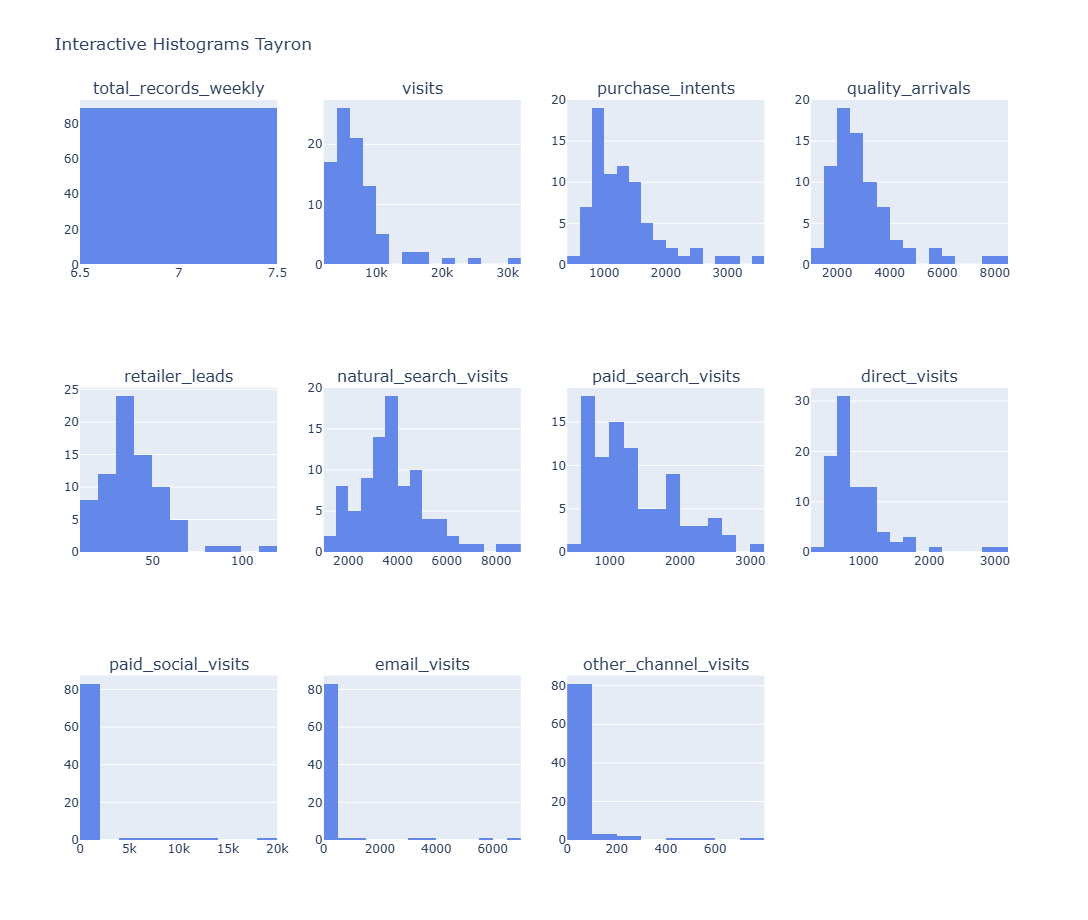

In [74]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import math
import pandas as pd

# 1. FIX: Convert to datetime first to avoid the AttributeError
Tayron_sorted['week_start'] = pd.to_datetime(Tayron_sorted['week_start'])

# 2. Create the formatted date string for the hover display
Tayron_sorted['week_start_str'] = Tayron_sorted['week_start'].dt.strftime('%Y-%m-%d')

# Identifying numerical columns
numerical_cols = [col for col in Tayron_sorted.select_dtypes(include=['number']).columns if col != 'week_start']
num_cols = len(numerical_cols)
rows = math.ceil(num_cols / 4)
cols = 4

fig = make_subplots(rows=rows, cols=cols, subplot_titles=numerical_cols)

for i, col in enumerate(numerical_cols, 1):
    row_idx = math.ceil(i / cols)
    col_idx = (i - 1) % cols + 1

    fig.add_trace(
        go.Histogram(
            x=Tayron_sorted[col],
            # 3. Use 'customdata' to pass the original dates to the binned trace
            customdata=Tayron_sorted['week_start_str'],
            nbinsx=15,
            name=col,
            # 4. Reference customdata in the template
            marker_color='#6488EA', 
            hovertemplate=(
                '<b>Week Start:</b> %{customdata}<br>'
                '<b>Value:</b> %{x}<br>'
                '<b>Count:</b> %{y}<extra></extra>'
            )
        ),
        row=row_idx,
        col=col_idx
    )

fig.update_layout(
    title_text='Interactive Histograms Tayron',
    height=300 * rows,
    width=1200,
    showlegend=False,
    template='plotly',
    # FIX: Set the hover label font color to white
    hoverlabel=dict(
        font_color="white",
        font_size=13,
        bgcolor="#2c3e50"  # Dark background makes white text pop
    )
)

fig.show()


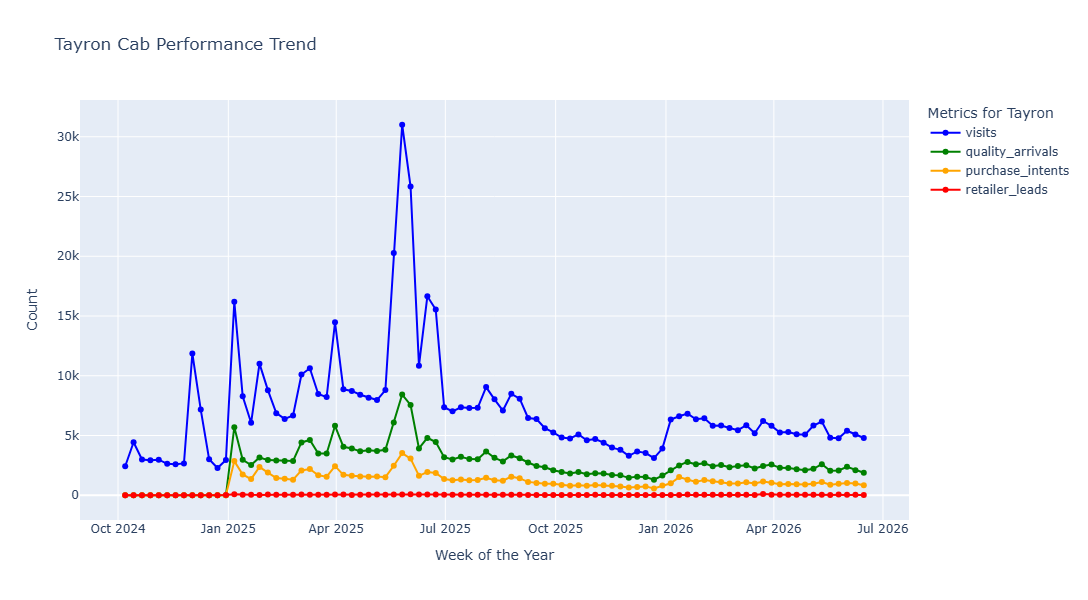

In [29]:
import plotly.express as px

# 1. Sort the DataFrame (ensure week_start is your x-axis)
Tayron_sorted = Tayron_sorted.sort_values(by='week_start', ascending=True)

# 2. Plot multiple columns by passing a list to 'y'
fig = px.line(
    Tayron_sorted,
    x='week_start',
    y=['visits', 'quality_arrivals', 'purchase_intents', 'retailer_leads'],  # List of columns
    title='Tayron Cab Performance Trend',
    markers=True,
    height=600,
    # Define custom colors for each column
    color_discrete_map={
        "visits": "blue",
        "quality_arrivals": "green",
        "purchase_intents": "orange",
        "retailer_leads": "red"
    }
)

# 3. Customizing labels and layout
fig.update_layout(
    xaxis_title='Week of the Year',
    yaxis_title='Count',
    legend_title='Metrics for Tayron',
    xaxis=dict(showgrid=True),
    yaxis=dict(showgrid=True)
)

# 4. Display the figure
fig.show()


In [78]:
import numpy as np

# Define the columns where we want to treat zeros as missing data
selected_columns = ['visits', 'quality_arrivals', 'purchase_intents', 'retailer_leads']

# Replace 0 with NaN only in those columns
Tayron_sorted[selected_columns] = Tayron_sorted[selected_columns].replace(0, np.nan)


In [79]:
# 1. Select only numeric columns to avoid string errors
Tayron_numeric = Tayron_sorted.select_dtypes(include=['number'])

# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = Tayron_numeric.quantile(0.25)
Q3 = Tayron_numeric.quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.8 * IQR
upper_bound = Q3 + 1.8 * IQR

# Count outliers per column
outliers_count = ((Tayron_numeric < lower_bound) | (Tayron_numeric > upper_bound)).sum()
print(outliers_count)


total_records_weekly      0
visits                    7
purchase_intents          3
quality_arrivals          5
retailer_leads            2
natural_search_visits     2
paid_search_visits        0
direct_visits             3
paid_social_visits       15
email_visits              6
other_channel_visits      5
dtype: int64


In [80]:
# 3. Identify all outliers across the entire numeric dataframe
outlier_mask = (Tayron_numeric < lower_bound) | (Tayron_numeric > upper_bound)

# 4. Extract outliers and their corresponding week_start
# We "stack" the data to get a row for every outlier found
outliers_stacked = Tayron_numeric[outlier_mask].stack().reset_index()
outliers_stacked.columns = ['index', 'column_name', 'outlier_value']

# 5. Map the original week_start dates back using the index
outliers_stacked['week_start'] = outliers_stacked['index'].map(Tayron_sorted['week_start'])

# 6. Final Clean Table
final_outliers = outliers_stacked[['week_start', 'column_name', 'outlier_value']]

#print("Outliers across all columns:")
#print(final_outliers)
final_outliers.style

,week_start,column_name,outlier_value
0,2024-12-02 00:00:00,direct_visits,3190.000000
1,2024-12-02 00:00:00,email_visits,6915.000000
2,2024-12-09 00:00:00,direct_visits,2010.000000
3,2025-01-06 00:00:00,visits,16200.000000
4,2025-01-06 00:00:00,purchase_intents,2856.000000
5,2025-01-06 00:00:00,quality_arrivals,5699.000000
6,2025-01-06 00:00:00,retailer_leads,92.000000
7,2025-01-06 00:00:00,direct_visits,2869.000000
8,2025-01-06 00:00:00,paid_social_visits,472.000000
9,2025-01-06 00:00:00,email_visits,5681.000000


In [81]:
import pandas as pd
import numpy as np

# List of numeric KPI columns
kpis = ['visits', 'quality_arrivals', 'purchase_intents', 'retailer_leads']

# Create a copy to preserve original if needed
Tayron_cleaned = Tayron_sorted.copy()

for col in kpis:
    # 1. Calculate IQR bounds
    Q1 = Tayron_cleaned[col].quantile(0.25)
    Q3 = Tayron_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.8 * IQR
    upper_bound = Q3 + 1.8 * IQR
    
    # 2. Mask values outside bounds with NaN
    # The mask() function replaces values where the condition is True
    Tayron_cleaned[col] = Tayron_cleaned[col].mask(
        (Tayron_cleaned[col] < lower_bound) | (Tayron_cleaned[col] > upper_bound), 
        np.nan
    )

# Tayron_cleaned now has week_start AND numeric NaNs for outliers
print(Tayron_cleaned.tail())

     week_start  total_records_weekly   model  visits  purchase_intents  \
236  2026-05-25                     7  Tayron  4776.0             953.0   
1060 2026-06-01                     7  Tayron  5397.0            1022.0   
456  2026-06-08                     7  Tayron  5094.0             990.0   
1112 2026-06-15                     7  Tayron  4792.0             833.0   
1692 2026-06-22                     7  Tayron  4314.0             759.0   

      quality_arrivals  retailer_leads  natural_search_visits  \
236             2070.0            54.0                   2764   
1060            2379.0            35.0                   2916   
456             2097.0            33.0                   2777   
1112            1882.0            31.0                   2591   
1692            1768.0            17.0                   2405   

      paid_search_visits  direct_visits  paid_social_visits  email_visits  \
236                 1252            546                  60            31   
1060

In [87]:
import pandas as pd
import numpy as np
from prophet import Prophet

Tayron = Tayron_cleaned.copy()

# 1. Data Preparation
Tayron['ds'] = pd.to_datetime(Tayron['week_start'])
kpis = ['visits', 'quality_arrivals', 'purchase_intents', 'retailer_leads']

# 1. Initialize storage dictionaries
final_forecasts = {}
mape_scores = {}
mae_scores = {} 



for kpi in kpis:
    print(f"Processing model for: {kpi}")
    
    # 2. Strategic Transformation
    # Square root is better for count data (0-900) than logs
    if kpi == 'retailer_leads':
        Tayron['y'] = np.sqrt(Tayron[kpi])
        # Use a more stable trend for skewed leads
        m = Prophet(seasonality_mode='additive')#, changepoint_prior_scale=0.01)
    else:
        Tayron['y'] = np.log1p(Tayron[kpi])
        m = Prophet(seasonality_mode='additive')
        
    m.add_country_holidays(country_name='UK')
    m.fit(Tayron[['ds', 'y']])
    
    # 3. Forecast
    full_timeline_df = m.make_future_dataframe(periods=28, freq='W-MON')
    forecast = m.predict(full_timeline_df)
    
    # 4. Inverse Transformation (Back to original scale)
    if kpi == 'retailer_leads':
        for col in ['yhat', 'yhat_lower', 'yhat_upper']:
            forecast[col] = np.square(forecast[col]) # Square is inverse of Sqrt
    else:
        for col in ['yhat', 'yhat_lower', 'yhat_upper']:
            forecast[col] = np.expm1(forecast[col])
    
    # 5. Calculate Metrics
    performance_df = forecast.set_index('ds').join(Tayron.set_index('ds')[[kpi]], how='inner')
    
    # Calculate MAE (robust to zeros and spikes)
    mae = np.mean(np.abs(performance_df[kpi] - performance_df['yhat']))
    mae_scores[kpi] = mae
    
    # Calculate MAPE (handling zeros with .replace to avoid infinite error)
    mape = np.mean(np.abs((performance_df[kpi] - performance_df['yhat']) / performance_df[kpi].replace(0, np.nan))) * 100
    mape_scores[kpi] = mape
    
    final_forecasts[kpi] = forecast

# 6. Output Results
print("\n--- Model Performance ---")
for kpi in kpis:
    print(f"{kpi} | MAE: {mae_scores[kpi]:.2f} | MAPE: {mape_scores[kpi]:.2f}%")


Processing model for: visits


12:45:07 - cmdstanpy - INFO - Chain [1] start processing
12:45:07 - cmdstanpy - INFO - Chain [1] done processing
12:45:08 - cmdstanpy - INFO - Chain [1] start processing


Processing model for: quality_arrivals


12:45:08 - cmdstanpy - INFO - Chain [1] done processing
12:45:08 - cmdstanpy - INFO - Chain [1] start processing


Processing model for: purchase_intents


12:45:09 - cmdstanpy - INFO - Chain [1] done processing


Processing model for: retailer_leads


12:45:09 - cmdstanpy - INFO - Chain [1] start processing
12:45:09 - cmdstanpy - INFO - Chain [1] done processing



--- Model Performance ---
visits | MAE: 1100.16 | MAPE: 20.40%
quality_arrivals | MAE: 263.42 | MAPE: 9.95%
purchase_intents | MAE: 183.53 | MAPE: 14.67%
retailer_leads | MAE: 9.80 | MAPE: 33.03%


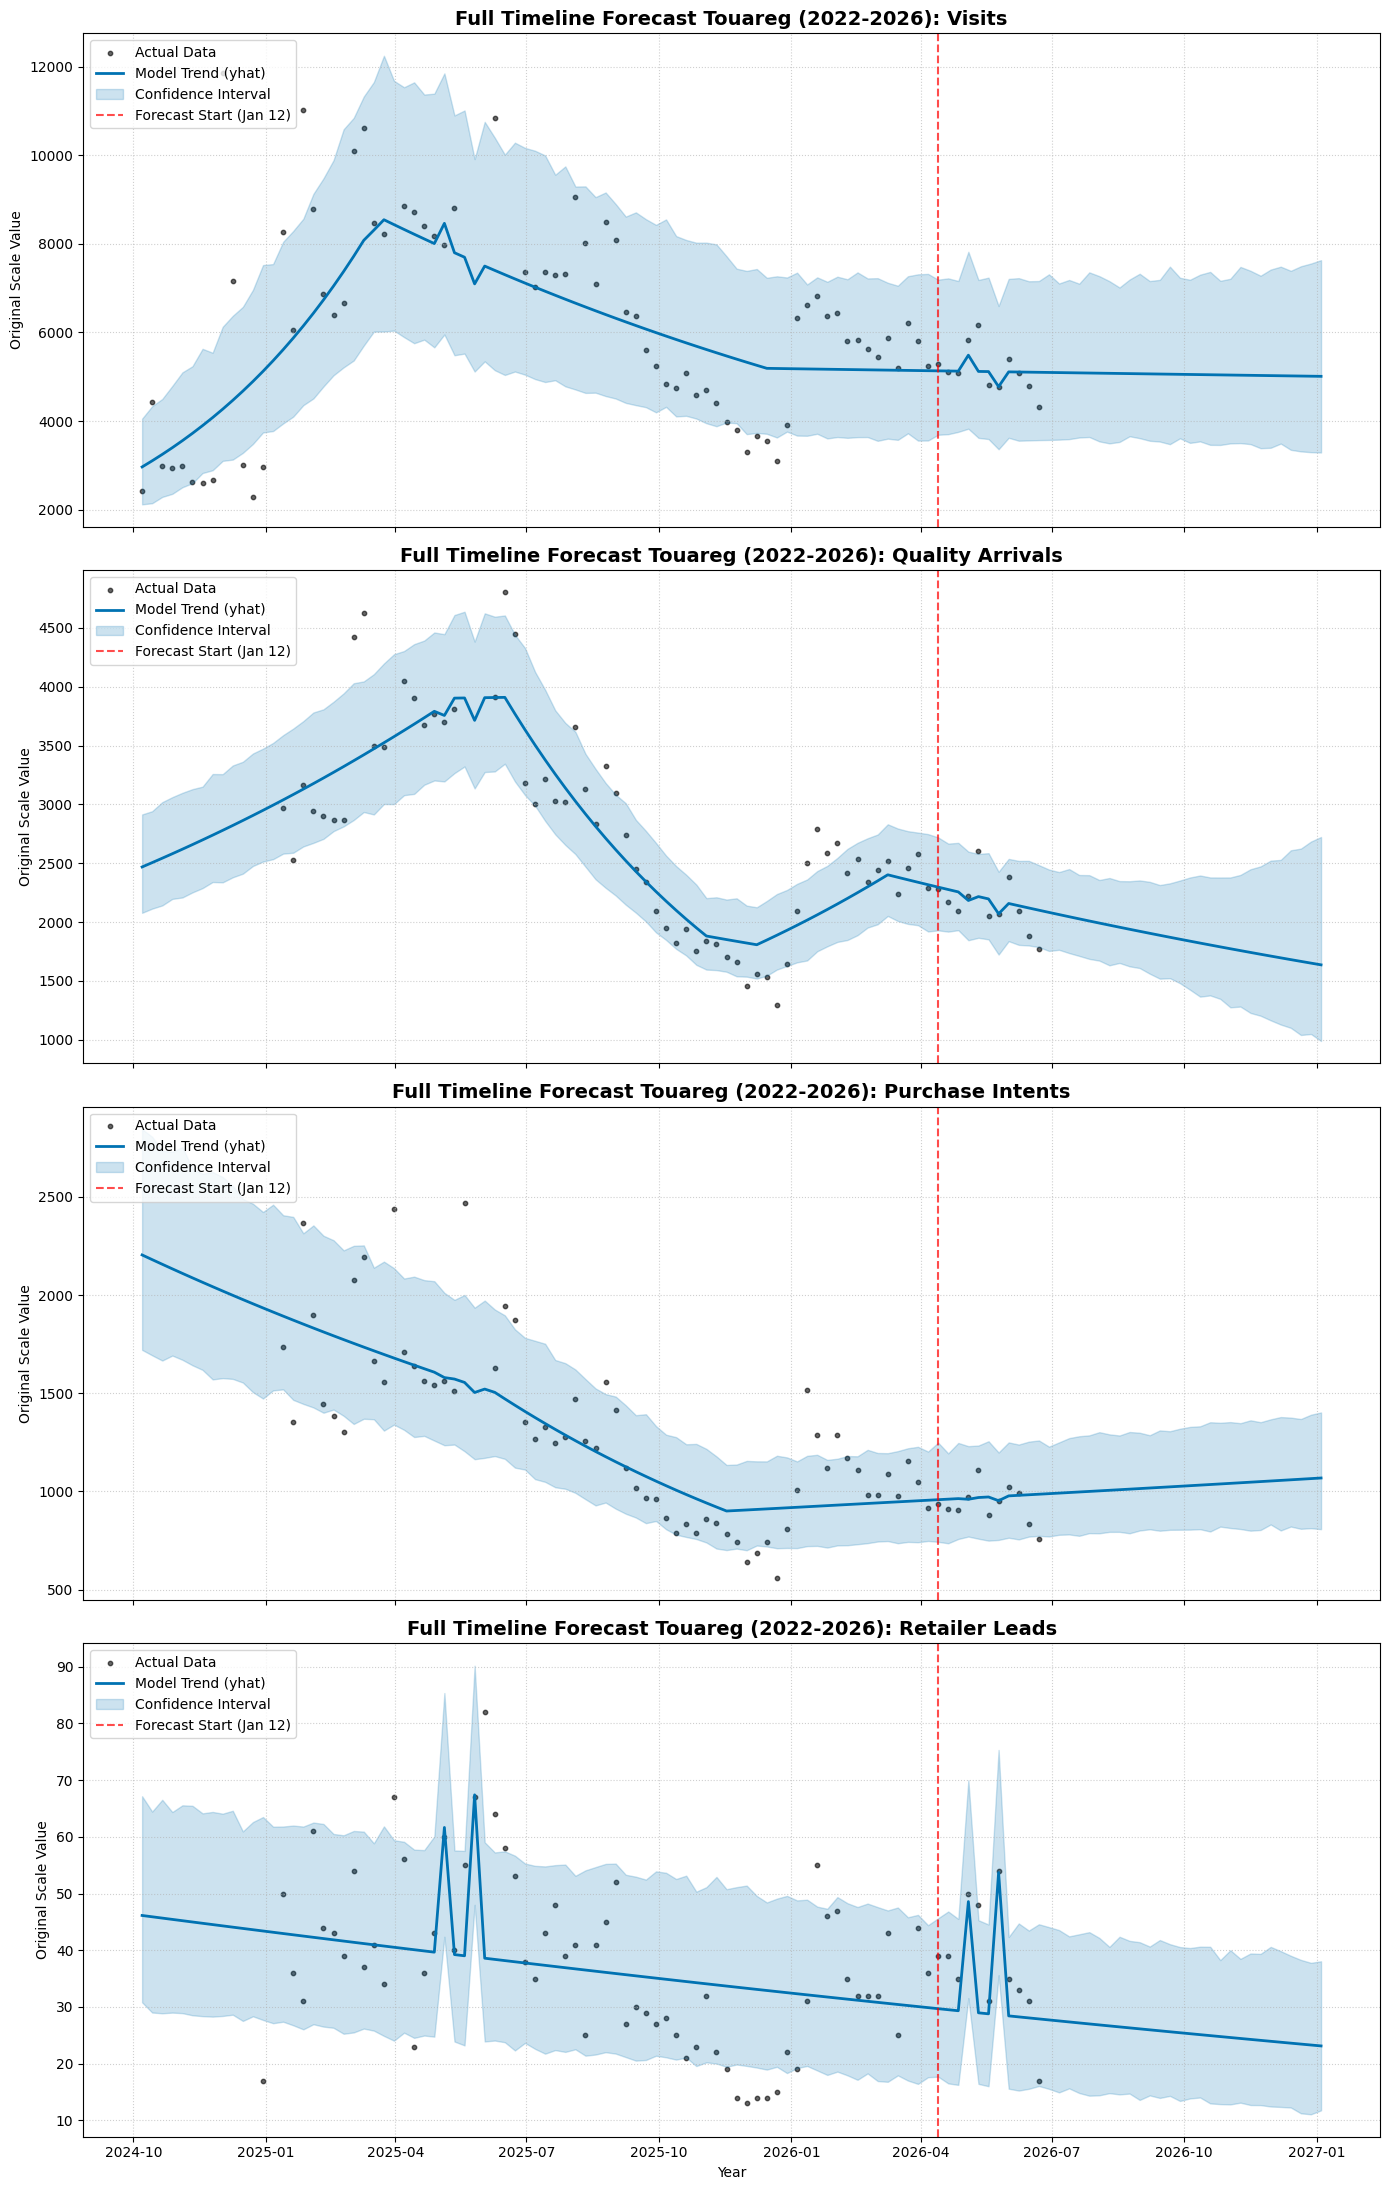

In [88]:

# 7. Visualization: Full Timeline (Actuals vs Predicted)
fig, axes = plt.subplots(4, 1, figsize=(14, 22), sharex=True)

for i, kpi in enumerate(kpis):
    ax = axes[i]
    forecast_df = final_forecasts[kpi]
    
    # Plot Historical Actuals as black dots
    ax.scatter(Tayron['ds'], Tayron[kpi], color='black', label='Actual Data', s=10, alpha=0.6)
    
    # Plot Continuous Model Trend Line (History + Future)
    ax.plot(forecast_df['ds'], forecast_df['yhat'], color='#0072B2', label='Model Trend (yhat)', linewidth=2)
    
    # Plot Confidence Intervals (Shaded Area)
    ax.fill_between(forecast_df['ds'], forecast_df['yhat_lower'], forecast_df['yhat_upper'], 
                    color='#0072B2', alpha=0.2, label='Confidence Interval')
    
    # Add a vertical line to mark the start of the 2026 Forecast
    ax.axvline(pd.to_datetime('2026-04-13'), color='red', linestyle='--', alpha=0.7, label='Forecast Start (Jan 12)')
    
    # Formatting
    ax.set_title(f'Full Timeline Forecast Touareg (2022-2026): {kpi.replace("_", " ").title()}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Original Scale Value')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper left')

plt.xlabel('Year')
plt.tight_layout()
plt.show()


In [89]:

# --- 8. NEW: Combine into one final dataframe ---
# This merges all 4 KPI dataframes together vertically
#combined_forecast_df = pd.concat(final_forecasts.values(), ignore_index=True)

# --- 8. Build Long-Format Final Output Dataframe (Fixed Column Names) ---

long_df_list = []

for kpi in kpis:
    # 1. Isolate the specific forecast for this KPI (Keep original names)
    forecast_df = final_forecasts[kpi][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    forecast_df = forecast_df.rename(columns={'ds': 'week_start'})
    
    # 2. Isolate and merge the actuals for this specific KPI
    actuals_df = Tayron[['ds', kpi]].copy()
    actuals_df = actuals_df.rename(columns={'ds': 'week_start', kpi: 'actual'})
    
    # Combine forecast and actuals for this KPI
    kpi_df = pd.merge(forecast_df, actuals_df, on='week_start', how='outer')
    
    # 3. Create the 'kpi' column and label the row
    kpi_df['kpi'] = kpi
    
    # 4. Create the 'data_type' flag
    kpi_df['data_type'] = np.where(kpi_df['actual'].isna(), 'Forecast', 'Actual')
    
    # 5. Create the base value column (blends Actual for history, yhat for future)
    kpi_df['value'] = kpi_df['actual'].fillna(kpi_df['yhat'])
    
    # Append to our list
    long_df_list.append(kpi_df)

# Combine all 4 KPI datasets vertically
final_output_df = pd.concat(long_df_list, ignore_index=True)

# 6. Reorder columns to ensure all requested targets exist
column_order = ['week_start', 'kpi', 'value', 'data_type', 'actual', 'yhat', 'yhat_lower', 'yhat_upper']
final_output_df = final_output_df[column_order]

# Sort chronologically by KPI group
final_output_df = final_output_df.sort_values(['kpi', 'week_start']).reset_index(drop=True)



In [90]:
final_output_df

,week_start,kpi,value,data_type,actual,yhat,yhat_lower,yhat_upper
0,2024-10-07,purchase_intents,2204.576001,Forecast,NaN,2204.576001,1721.087640,2845.692130
1,2024-10-14,purchase_intents,2180.712594,Forecast,NaN,2180.712594,1693.264192,2806.168446
2,2024-10-21,purchase_intents,2157.107380,Forecast,NaN,2157.107380,1666.652583,2734.968350
3,2024-10-28,purchase_intents,2133.757564,Forecast,NaN,2133.757564,1691.990407,2729.682520
4,2024-11-04,purchase_intents,2110.660383,Forecast,NaN,2110.660383,1670.527599,2754.402320
...,...,...,...,...,...,...,...,...
467,2026-12-07,visits,5023.073066,Forecast,NaN,5023.073066,3491.375399,7486.798502
468,2026-12-14,visits,5019.848765,Forecast,NaN,5019.848765,3350.447520,7392.700865
469,2026-12-21,visits,5016.626533,Forecast,NaN,5016.626533,3315.140092,7495.950845
470,2026-12-28,visits,5013.406369,Forecast,NaN,5013.406369,3297.398838,7557.538315


In [91]:
# Separate DataFrames for each kpi starting current week in 2026
Tayron_visits_forecast = final_output_df[final_output_df['kpi'] == 'visits'].copy()
Tayron_purchase_intents_forecast = final_output_df[final_output_df['kpi'] == 'purchase_intents'].copy()
Tayron_quality_arrivals_forecast = final_output_df[final_output_df['kpi'] == 'quality_arrivals'].copy()
Tayron_retailer_leads_forecast = final_output_df[final_output_df['kpi'] == 'retailer_leads'].copy()

# Optional: Remove the 'kpi' column for a clean output for each
Tayron_visits_forecast.drop(columns=['kpi'], inplace=True)
Tayron_purchase_intents_forecast.drop(columns=['kpi'], inplace=True)
Tayron_quality_arrivals_forecast.drop(columns=['kpi'], inplace=True)
Tayron_retailer_leads_forecast.drop(columns=['kpi'], inplace=True)

# Select relevant columns for final output/plotting
Tayron_visits_forecast = Tayron_visits_forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']]
forecast_v = Tayron_visits_forecast.copy()
Tayron_purchase_intents_forecast = Tayron_purchase_intents_forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']]
forecast_pi = Tayron_purchase_intents_forecast.copy()
Tayron_quality_arrivals_forecast = Tayron_quality_arrivals_forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']]
forecast_qa = Tayron_quality_arrivals_forecast.copy()
Tayron_retailer_leads_forecast = Tayron_retailer_leads_forecast[['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']]
forecast_rl = Tayron_retailer_leads_forecast.copy()

# 1. CLEANING 
forecast_v.columns = [
    col.replace(' ', '_')
       .replace('(', '')
       .replace(')', '')
       .replace("'", "")
       .replace('-', '_') 
    for col in forecast_v.columns
]
# Select only what is needed
target_cols = ['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']
forecast_cleaned_v = forecast_v[target_cols].copy()

# 1a. CLEANING 
forecast_pi.columns = [
    col.replace(' ', '_')
       .replace('(', '')
       .replace(')', '')
       .replace("'", "")
       .replace('-', '_') 
    for col in forecast_pi.columns
]
# Select only what is needed
target_cols = ['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']
forecast_cleaned_pi = forecast_pi[target_cols].copy()

# 1b. CLEANING 
forecast_qa.columns = [
    col.replace(' ', '_')
       .replace('(', '')
       .replace(')', '')
       .replace("'", "")
       .replace('-', '_') 
    for col in forecast_qa.columns
]

# Select only what is needed
target_cols = ['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']
forecast_cleaned_qa = forecast_qa[target_cols].copy()

# 1c. CLEANING 
forecast_rl.columns = [
    col.replace(' ', '_')
       .replace('(', '')
       .replace(')', '')
       .replace("'", "")
       .replace('-', '_') 
    for col in forecast_rl.columns
]

# Select only what is needed
target_cols = ['week_start', 'yhat', 'yhat_lower', 'yhat_upper', 'actual']
forecast_cleaned_rl = forecast_rl[target_cols].copy()

import time

# 2. DATABASE OPERATIONS
try:
    conn = redshift_connector.connect(**conn_args)
    conn.autocommit = True 
    cursor = conn.cursor()

    cols_definition = "week_start TIMESTAMP, yhat FLOAT, yhat_lower FLOAT, yhat_upper FLOAT, actual FLOAT"

    # --- STEP 1: DROP, WAIT, AND CREATE TABLES ---
    tables = {
        "af_tribal.m_Tayron_Forecast_Visits": forecast_cleaned_v,
        "af_tribal.m_Tayron_Forecast_PIs": forecast_cleaned_pi,
        "af_tribal.m_Tayron_Forecast_QAs": forecast_cleaned_qa,
        "af_tribal.m_Tayron_Forecast_RLs": forecast_cleaned_rl
    }

    for table_name in tables.keys():
        cursor.execute(f"DROP TABLE IF EXISTS {table_name};")
        time.sleep(3) # Wait for Redshift catalog update
        cursor.execute(f"CREATE TABLE {table_name} ({cols_definition});")
        print(f"Table {table_name} created successfully.")
    
    conn.commit()

    # --- STEP 2: PREPARE AND INSERT DATA INDIVIDUALLY ---
    
    # A. Insert Visits
    print("Inserting data into Tayron_Forecast_Visits...")
    df_v = forecast_cleaned_v.where(pd.notna(forecast_cleaned_v), None)
    df_v['week_start'] = pd.to_datetime(df_v['week_start']).dt.strftime('%Y-%m-%d %H:%M:%S')
    tuples_v = [tuple(x) for x in df_v.to_numpy()]
    sql_v = f"INSERT INTO af_tribal.m_Tayron_Forecast_Visits (week_start, yhat, yhat_lower, yhat_upper, actual) VALUES (%s, %s, %s, %s, %s)"
    cursor.executemany(sql_v, tuples_v)
    conn.commit()

    # B. Insert PIs
    print("Inserting data into Tayron_Forecast_PIs...")
    df_pi = forecast_cleaned_pi.where(pd.notna(forecast_cleaned_pi), None)
    df_pi['week_start'] = pd.to_datetime(df_pi['week_start']).dt.strftime('%Y-%m-%d %H:%M:%S')
    tuples_pi = [tuple(x) for x in df_pi.to_numpy()]
    sql_pi = f"INSERT INTO af_tribal.m_Tayron_Forecast_PIs (week_start, yhat, yhat_lower, yhat_upper, actual) VALUES (%s, %s, %s, %s, %s)"
    cursor.executemany(sql_pi, tuples_pi)
    conn.commit()

    # C. Insert QAs
    print("Inserting data into Tayron_Forecast_QAs...")
    df_qa = forecast_cleaned_qa.where(pd.notna(forecast_cleaned_qa), None)
    df_qa['week_start'] = pd.to_datetime(df_qa['week_start']).dt.strftime('%Y-%m-%d %H:%M:%S')
    tuples_qa = [tuple(x) for x in df_qa.to_numpy()]
    sql_qa = f"INSERT INTO af_tribal.m_Tayron_Forecast_QAs (week_start, yhat, yhat_lower, yhat_upper, actual) VALUES (%s, %s, %s, %s, %s)"
    cursor.executemany(sql_qa, tuples_qa)
    conn.commit()

    # C. Insert RLs
    print("Inserting data into Tayron_Forecast_RLs...")
    df_rl = forecast_cleaned_rl.where(pd.notna(forecast_cleaned_rl), None)
    df_rl['week_start'] = pd.to_datetime(df_rl['week_start']).dt.strftime('%Y-%m-%d %H:%M:%S')
    tuples_rl = [tuple(x) for x in df_rl.to_numpy()]
    sql_rl = f"INSERT INTO af_tribal.m_Tayron_Forecast_RLs (week_start, yhat, yhat_lower, yhat_upper, actual) VALUES (%s, %s, %s, %s, %s)"
    cursor.executemany(sql_rl, tuples_rl)
    conn.commit()

    print("Success: All 4 kpi forecasts pushed to Redshift.")

except Exception as e:
    print(f"Error occurred: {e}")
    raise 
finally:
    cursor.close()
    conn.close()
      


Table af_tribal.m_Tayron_Forecast_Visits created successfully.
Table af_tribal.m_Tayron_Forecast_PIs created successfully.
Table af_tribal.m_Tayron_Forecast_QAs created successfully.
Table af_tribal.m_Tayron_Forecast_RLs created successfully.
Inserting data into Tayron_Forecast_Visits...
Inserting data into Tayron_Forecast_PIs...
Inserting data into Tayron_Forecast_QAs...
Inserting data into Tayron_Forecast_RLs...
Success: All 4 kpi forecasts pushed to Redshift.


In [16]:
# Trying Yeo-Johnson transformation but would still go ahead with sqrt transformation above for leads in the next step as it is giving better results.

import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.preprocessing import PowerTransformer

Tayron = Tayron_cleaned.copy()

# 1. Data Preparation
Tayron['ds'] = pd.to_datetime(Tayron['week_start'])
kpis = ['visits', 'quality_arrivals', 'purchase_intents', 'retailer_leads']

# Initialize storage dictionaries
final_forecasts = {}
mape_scores = {}
mae_scores = {} 
transformers = {} # Store transformers to invert the forecast later

for kpi in kpis:
    print(f"Processing model for: {kpi}")
    
    # 2. Dynamic Yeo-Johnson Transformation
    # Reshape data to 2D array as required by scikit-learn
    kpi_data = Tayron[[kpi]].values
    
    # Initialize and fit the Yeo-Johnson power transformer
    pt = PowerTransformer(method='yeo-johnson', standardize=False)
    Tayron['y'] = pt.fit_transform(kpi_data)
    transformers[kpi] = pt # Save for inverse transformation
    
    # Configure Prophet
    m = Prophet(seasonality_mode='additive')
    m.add_country_holidays(country_name='UK')
    m.fit(Tayron[['ds', 'y']])
    
    # 3. Forecast
    full_timeline_df = m.make_future_dataframe(periods=12, freq='W-MON')
    forecast = m.predict(full_timeline_df)
    
    # 4. Inverse Transformation (Back to original scale)
    for col in ['yhat', 'yhat_lower', 'yhat_upper']:
        # Reshape to 2D, inverse transform, and flatten back to 1D
        col_data = forecast[[col]].values
        forecast[col] = pt.inverse_transform(col_data).flatten()
        
    # Prevent negative values if your original data is strictly non-negative
    for col in ['yhat', 'yhat_lower', 'yhat_upper']:
        forecast[col] = np.clip(forecast[col], 0, None)
    
    # 5. Calculate Metrics
    performance_df = forecast.set_index('ds').join(Tayron.set_index('ds')[[kpi]], how='inner')
    
    # Calculate MAE (robust to zeros and spikes)
    mae = np.mean(np.abs(performance_df[kpi] - performance_df['yhat']))
    mae_scores[kpi] = mae
    
    # Calculate MAPE (handling zeros with .replace to avoid infinite error)
    mape = np.mean(np.abs((performance_df[kpi] - performance_df['yhat']) / performance_df[kpi].replace(0, np.nan))) * 100
    mape_scores[kpi] = mape
    
    final_forecasts[kpi] = forecast

# 6. Output Results
print("\n--- Model Performance ---")
for kpi in kpis:
    print(f"{kpi} | MAE: {mae_scores[kpi]:.2f} | MAPE: {mape_scores[kpi]:.2f}%")


Processing model for: visits


13:18:44 - cmdstanpy - INFO - Chain [1] start processing
13:18:45 - cmdstanpy - INFO - Chain [1] done processing


Processing model for: quality_arrivals


13:18:45 - cmdstanpy - INFO - Chain [1] start processing
13:18:46 - cmdstanpy - INFO - Chain [1] done processing


Processing model for: purchase_intents


13:18:46 - cmdstanpy - INFO - Chain [1] start processing
13:18:47 - cmdstanpy - INFO - Chain [1] done processing


Processing model for: retailer_leads


13:18:47 - cmdstanpy - INFO - Chain [1] start processing
13:18:48 - cmdstanpy - INFO - Chain [1] done processing



--- Model Performance ---
visits | MAE: 1715.06 | MAPE: 34.48%
quality_arrivals | MAE: 263.25 | MAPE: 9.97%
purchase_intents | MAE: 143.46 | MAPE: 10.79%
retailer_leads | MAE: 9.27 | MAPE: 32.26%
